# TESTING - Random search algorithm

In [1]:
METHOD = "RANDOM"

In [2]:
import io
import os
import random
import torch
import json
import contextlib
from ultralytics import YOLO 
from mylib import simsettings
from mylib import myutils
from mylib import simtools
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import ACTIONS   
from constants import NUM_EPOCHS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")  

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [4]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration (index selects the simulation)
simulation = simulations[31]

# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

In [5]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
num_free_cells = len(grid_free_cells)

In [6]:
starting_grid_positions = []
starting_orientations = []

for _ in range(NUM_EPOCHS):
    # Randomly select a free cell
    starting_grid_positions.append(random.choice(grid_free_cells))
    starting_orientations.append(random.choice([0, 90, 180, 270])) # Random orientation in degrees

# Print it like it was a list
print("starting_grid_positions = [", end="")
for pos in starting_grid_positions:
    print(f"{pos}, ", end="")
print("]")

print("starting_orientations = [", end="")
for ori in starting_orientations:
    print(f"{ori}, ", end="")
print("]")

starting_grid_positions = [[13, 6], [12, 23], [4, 6], [10, 8], [13, 7], [30, 23], [31, 21], [18, 13], [31, 17], [8, 32], [21, 13], [4, 11], [20, 27], [1, 12], [11, 7], [20, 16], [16, 5], [30, 13], [19, 32], [27, 30], [20, 5], [31, 26], [10, 19], [13, 15], [5, 3], [10, 9], [27, 16], [14, 22], [7, 32], [16, 13], [29, 26], [19, 25], [30, 20], [14, 26], [20, 6], [30, 20], [15, 8], [25, 13], [8, 33], [17, 9], [16, 15], [12, 29], [16, 28], [26, 29], [16, 31], [11, 27], [18, 10], [6, 9], [11, 7], [33, 20], [17, 25], [13, 10], [19, 9], [25, 20], [11, 29], [16, 14], [4, 10], [13, 16], [23, 33], [21, 7], [18, 12], [20, 8], [19, 6], [5, 4], [17, 15], [6, 10], [17, 21], [16, 7], [22, 27], [19, 16], [24, 18], [7, 27], [26, 19], [16, 15], [11, 19], [18, 15], [31, 21], [14, 27], [7, 5], [30, 18], [16, 29], [23, 26], [17, 27], [21, 22], [32, 21], [27, 15], [9, 8], [6, 3], [3, 14], [4, 8], [23, 33], [3, 8], [15, 29], [7, 8], [22, 6], [20, 16], [13, 15], [13, 7], [20, 22], [27, 15], ]
starting_orientati

In [7]:
# Epochs metrics
num_actions_epochs = []
travelled_distance_epochs = []
success_epochs = []
location_error_epochs = []



Simulation 0/100

Location error 0.878 m exceeds threshold 0.8 m. FAILURE!


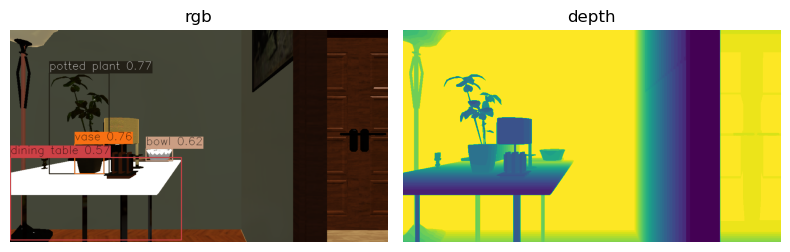

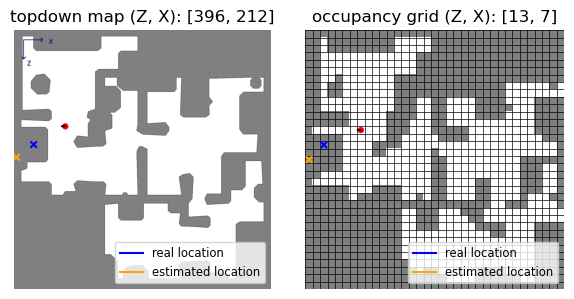


Target object <potted plant> not found after 4 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 4
Travelled distance: 0.30 m
Computed location error: 0.878 m


Simulation 1/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 23.41 m
Computed location error: inf m


Simulation 2/100

Location error 1.115 m exceeds threshold 0.8 m. FAILURE!


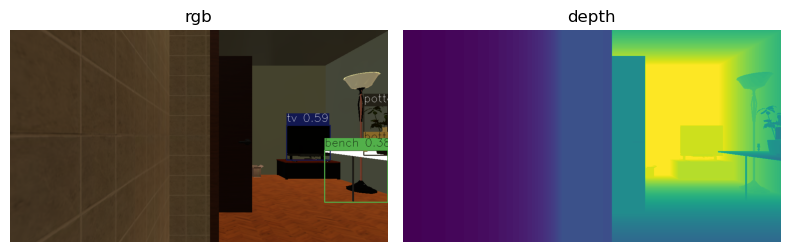

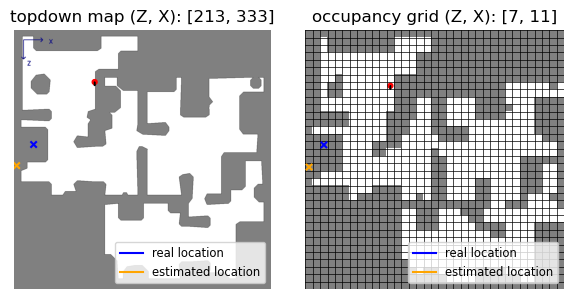


Target object <potted plant> not found after 101 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 101
Travelled distance: 6.69 m
Computed location error: 1.115 m


Simulation 3/100

Location error 0.968 m exceeds threshold 0.8 m. FAILURE!


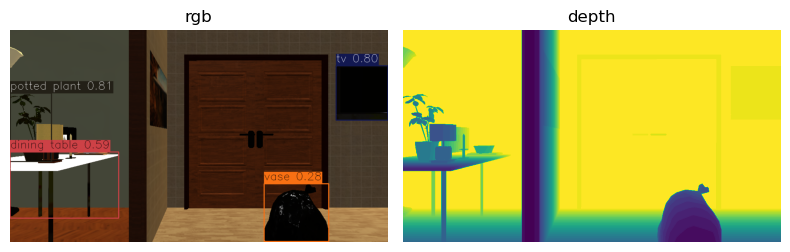

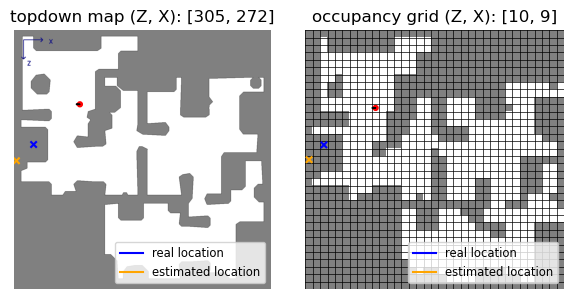


Target object <potted plant> not found after 6 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 6
Travelled distance: 0.30 m
Computed location error: 0.968 m


Simulation 4/100


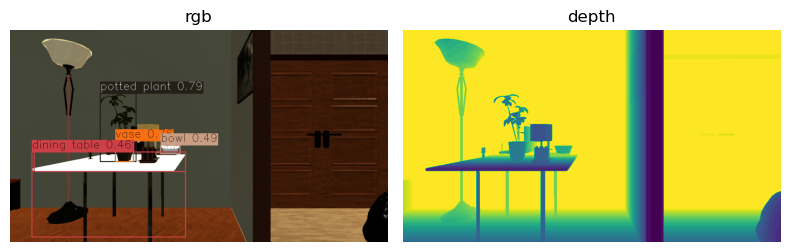

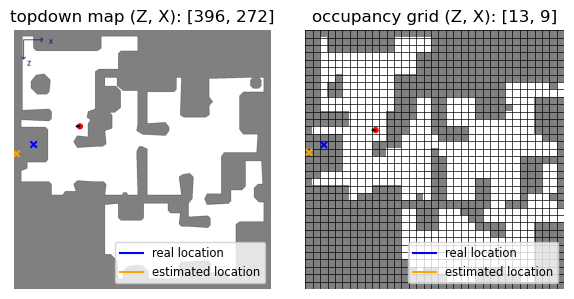


Target object <potted plant> found after 25 actions!
Found location: [    -10.375    -0.11255      6.7828]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 25
Travelled distance: 2.43 m
Computed location error: 0.797 m


Simulation 5/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 33.43 m
Computed location error: inf m


Simulation 6/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 39.24 m
Computed location error: inf m


Simulation 7/100


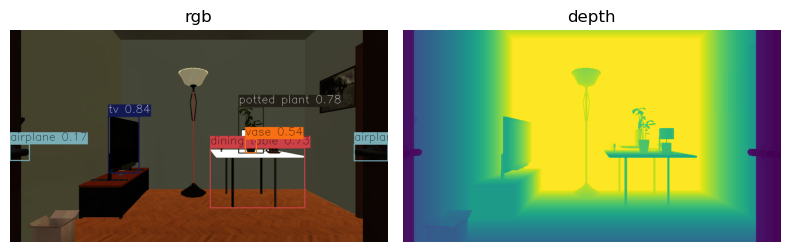

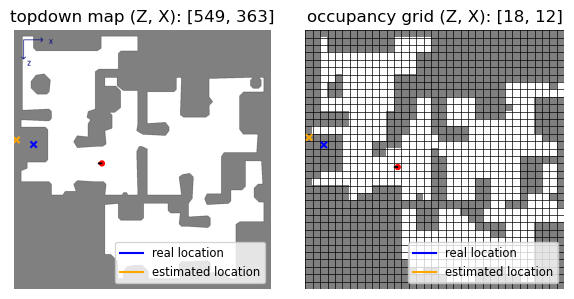


Target object <potted plant> found after 1 actions!
Found location: [    -10.375    -0.11025      6.2183]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 1
Travelled distance: 0.30 m
Computed location error: 0.730 m


Simulation 8/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 32.24 m
Computed location error: inf m


Simulation 9/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 15.48 m
Computed location error: inf m


Simulation 10/100


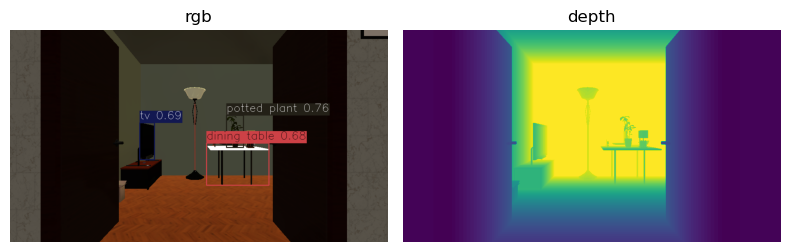

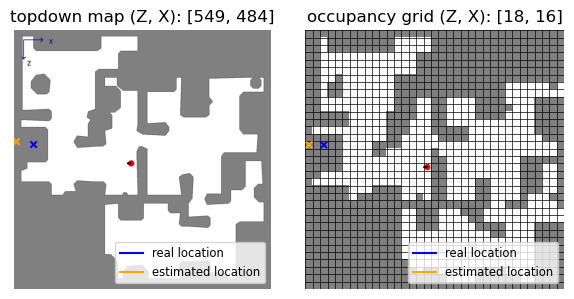


Target object <potted plant> found after 34 actions!
Found location: [    -10.376    -0.11109       6.285]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 34
Travelled distance: 3.04 m
Computed location error: 0.715 m


Simulation 11/100

Location error 0.968 m exceeds threshold 0.8 m. FAILURE!


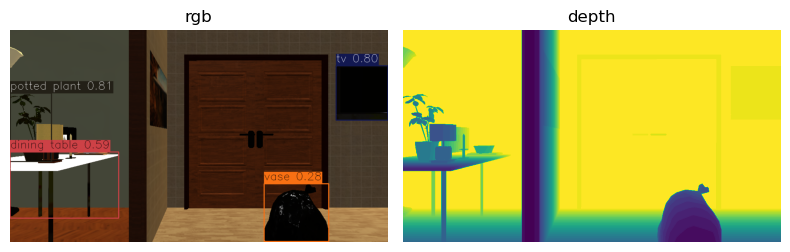

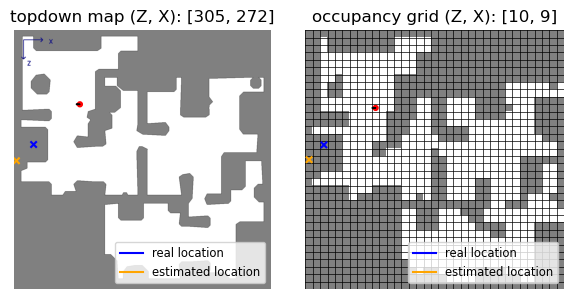


Target object <potted plant> not found after 155 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 155
Travelled distance: 13.98 m
Computed location error: 0.968 m


Simulation 12/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 27.96 m
Computed location error: inf m


Simulation 13/100

Location error 1.115 m exceeds threshold 0.8 m. FAILURE!


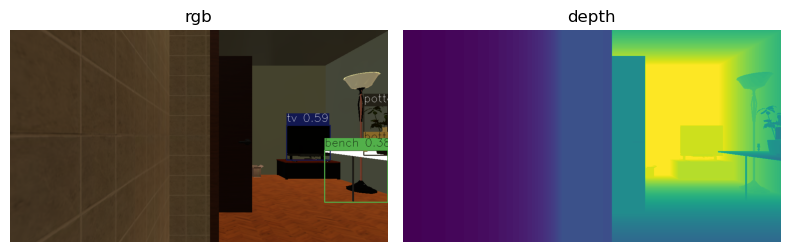

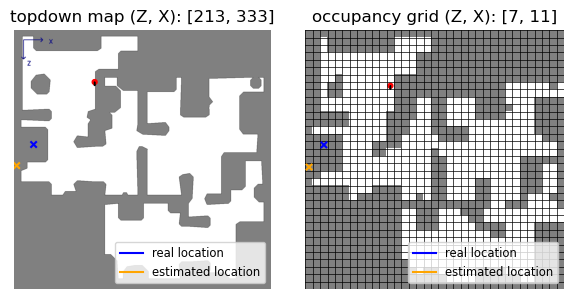


Target object <potted plant> not found after 150 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 150
Travelled distance: 8.22 m
Computed location error: 1.115 m


Simulation 14/100

Location error 1.125 m exceeds threshold 0.8 m. FAILURE!


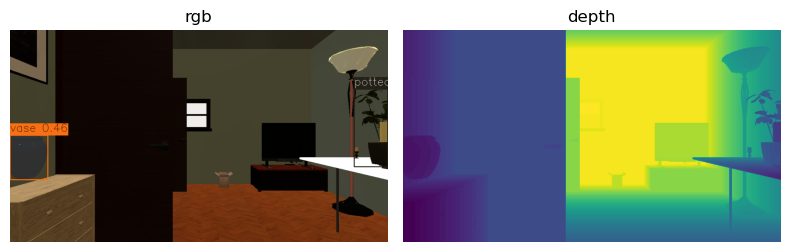

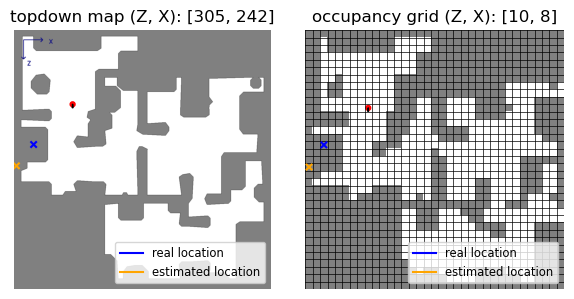


Target object <potted plant> not found after 44 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 44
Travelled distance: 4.27 m
Computed location error: 1.125 m


Simulation 15/100


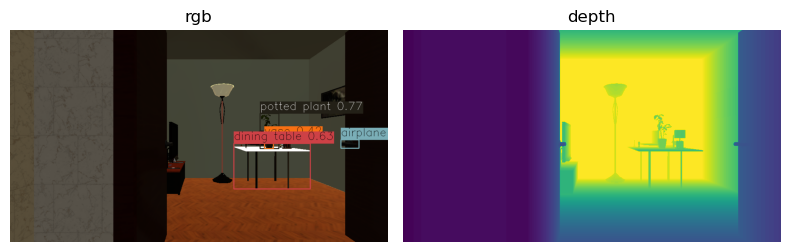

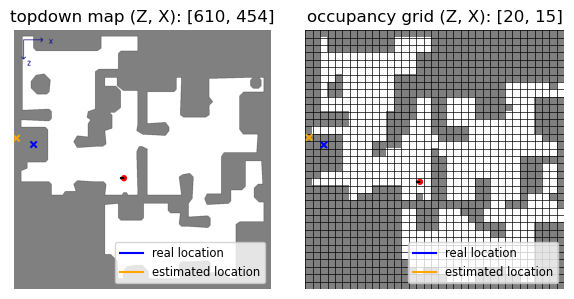


Target object <potted plant> found after 1 actions!
Found location: [    -10.375    -0.11266      6.1467]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 1
Travelled distance: 0.30 m
Computed location error: 0.752 m


Simulation 16/100

Location error 0.880 m exceeds threshold 0.8 m. FAILURE!


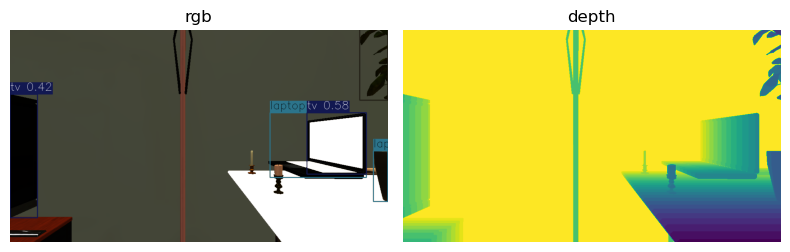

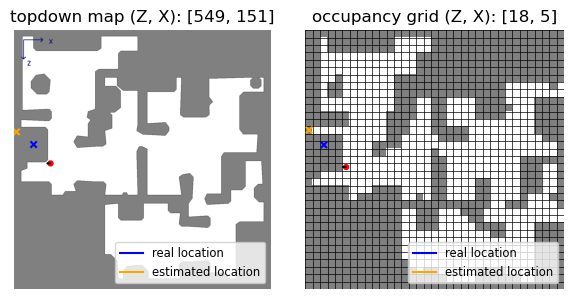


Target object <potted plant> not found after 13 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 13
Travelled distance: 0.61 m
Computed location error: 0.880 m


Simulation 17/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 33.42 m
Computed location error: inf m


Simulation 18/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 24.95 m
Computed location error: inf m


Simulation 19/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 29.48 m
Computed location error: inf m


Simulation 20/100

Location error 1.386 m e

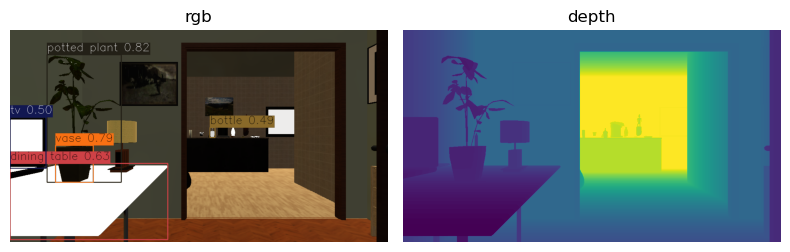

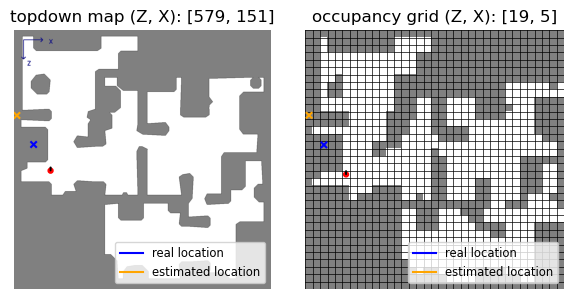


Target object <potted plant> not found after 1 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 1
Travelled distance: 0.31 m
Computed location error: 1.386 m


Simulation 21/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 27.98 m
Computed location error: inf m


Simulation 22/100


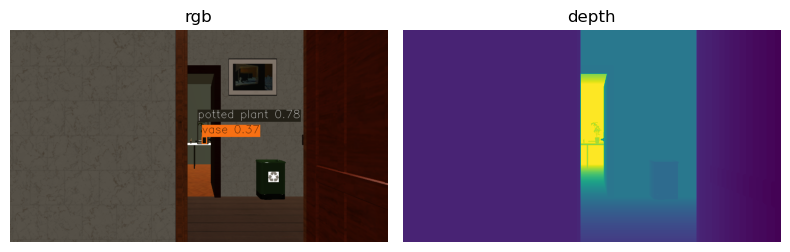

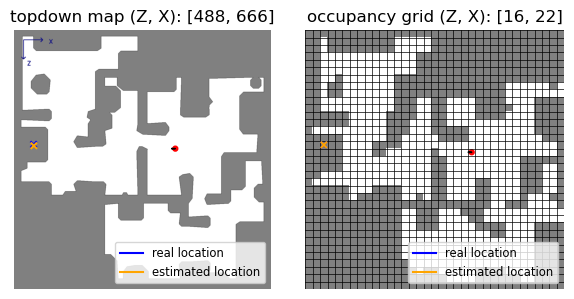


Target object <potted plant> found after 106 actions!
Found location: [    -9.6529   -0.091175      6.4587]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 106
Travelled distance: 8.22 m
Computed location error: 0.052 m


Simulation 23/100


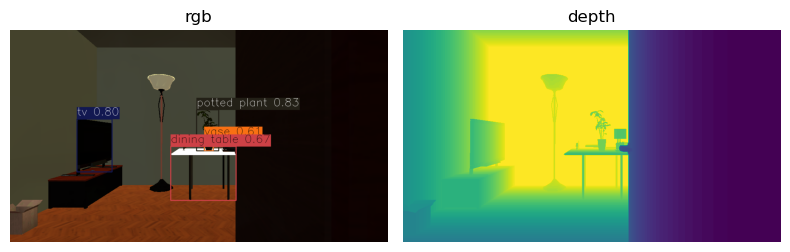

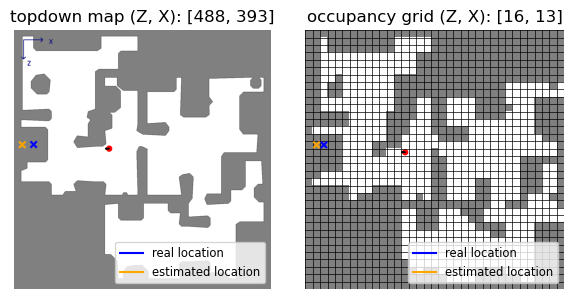


Target object <potted plant> found after 42 actions!
Found location: [    -10.134    -0.10518      6.4114]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 42
Travelled distance: 2.74 m
Computed location error: 0.463 m


Simulation 24/100


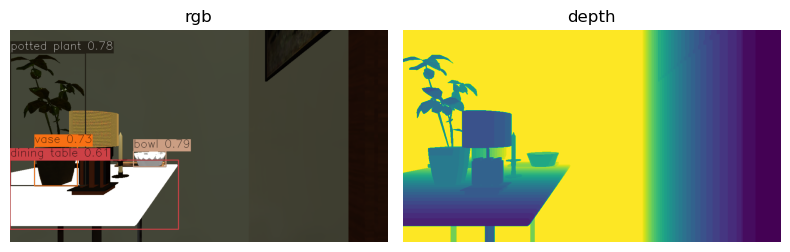

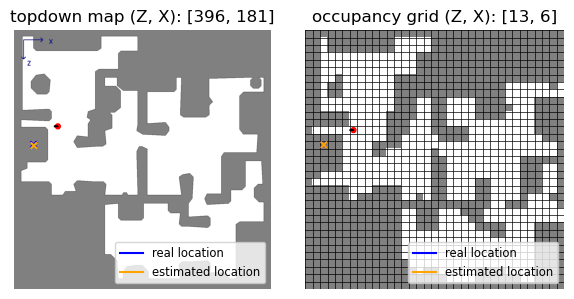


Target object <potted plant> found after 211 actions!
Found location: [    -9.6528   -0.084885      6.4482]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 211
Travelled distance: 12.50 m
Computed location error: 0.042 m


Simulation 25/100

Location error 0.926 m exceeds threshold 0.8 m. FAILURE!


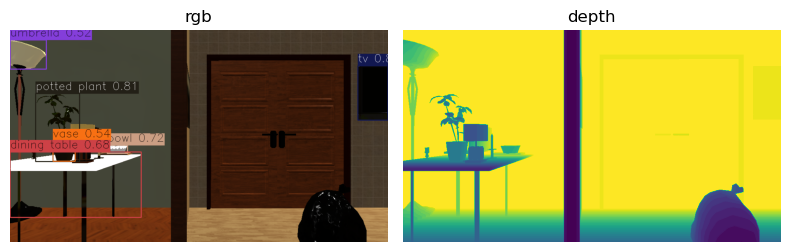

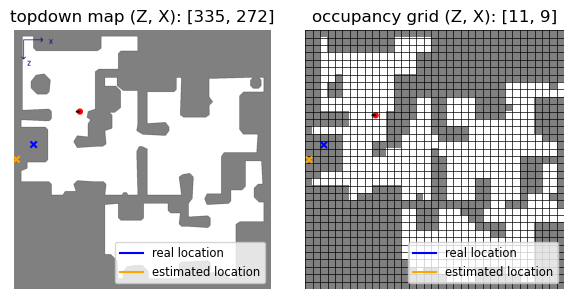


Target object <potted plant> not found after 5 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 5
Travelled distance: 0.31 m
Computed location error: 0.926 m


Simulation 26/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 24.91 m
Computed location error: inf m


Simulation 27/100


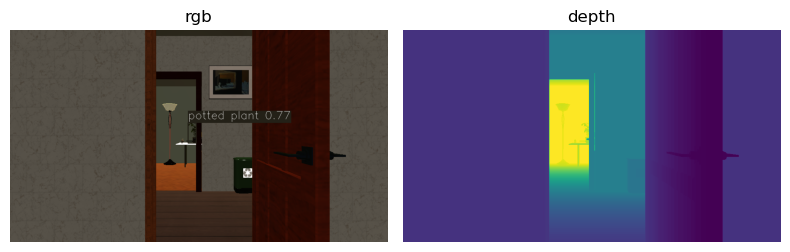

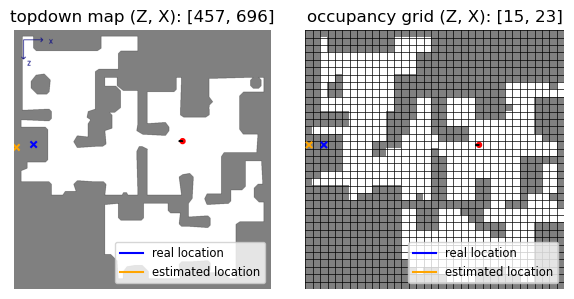


Target object <potted plant> found after 11 actions!
Found location: [    -10.376     -0.1072      6.5222]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 11
Travelled distance: 0.61 m
Computed location error: 0.713 m


Simulation 28/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 11.55 m
Computed location error: inf m


Simulation 29/100


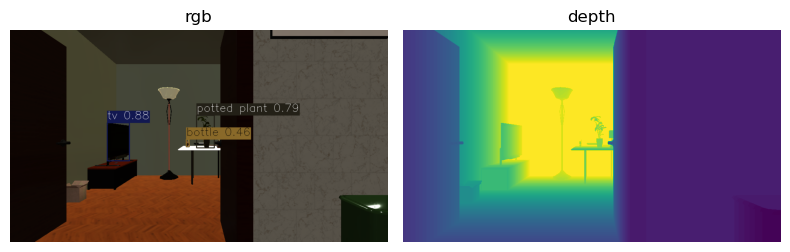

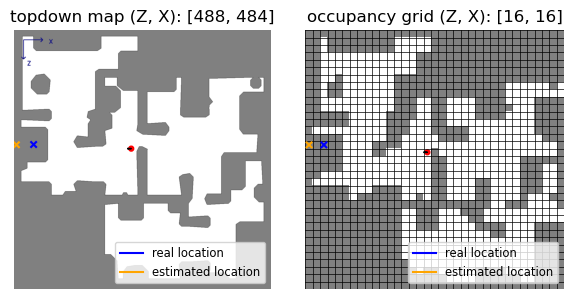


Target object <potted plant> found after 110 actions!
Found location: [    -10.376    -0.10184      6.4153]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 110
Travelled distance: 8.83 m
Computed location error: 0.704 m


Simulation 30/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 28.25 m
Computed location error: inf m


Simulation 31/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 27.37 m
Computed location error: inf m


Simulation 32/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 31.30 m
Computed location error:

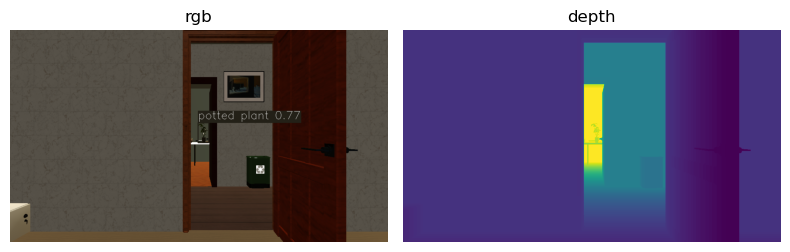

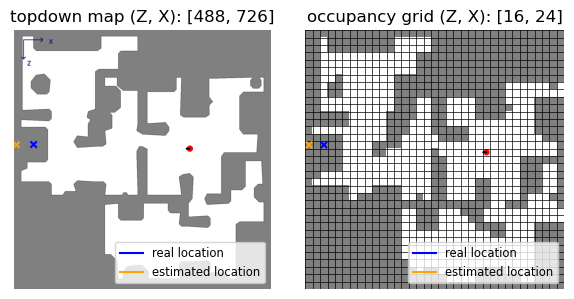


Target object <potted plant> found after 64 actions!
Found location: [    -10.375    -0.11193      6.4188]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 64
Travelled distance: 6.09 m
Computed location error: 0.704 m


Simulation 34/100


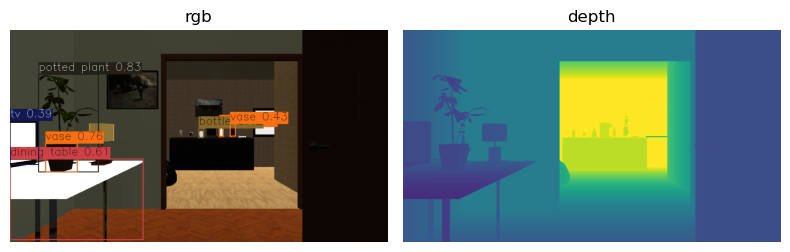

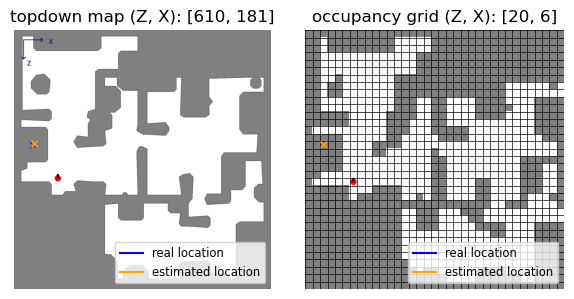


Target object <potted plant> found after 1 actions!
Found location: [    -9.6393   -0.093572      6.3842]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 1
Travelled distance: 0.00 m
Computed location error: 0.041 m


Simulation 35/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 28.91 m
Computed location error: inf m


Simulation 36/100


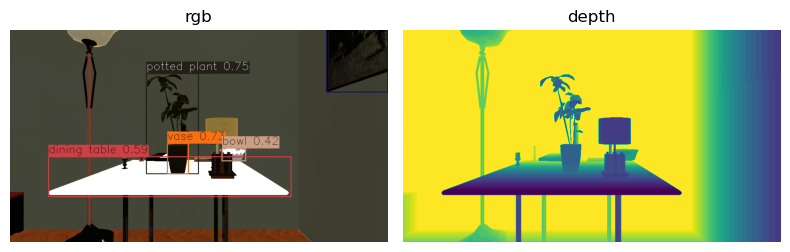

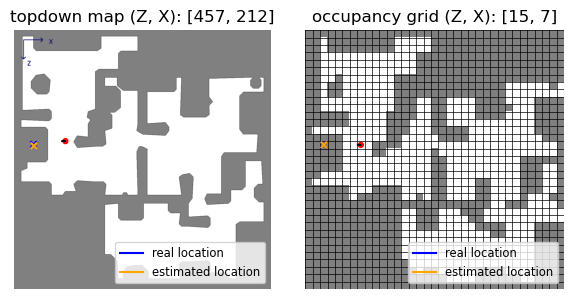


Target object <potted plant> found after 1 actions!
Found location: [    -9.6527   -0.083182      6.4516]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 1
Travelled distance: 0.30 m
Computed location error: 0.045 m


Simulation 37/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 31.62 m
Computed location error: inf m


Simulation 38/100


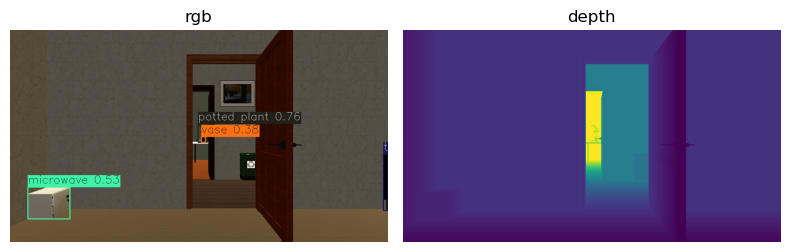

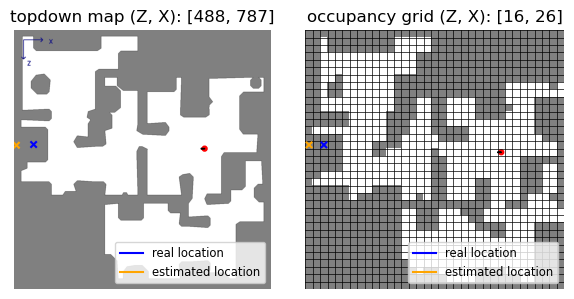


Target object <potted plant> found after 217 actions!
Found location: [    -10.375    -0.10622      6.4361]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 217
Travelled distance: 16.71 m
Computed location error: 0.705 m


Simulation 39/100


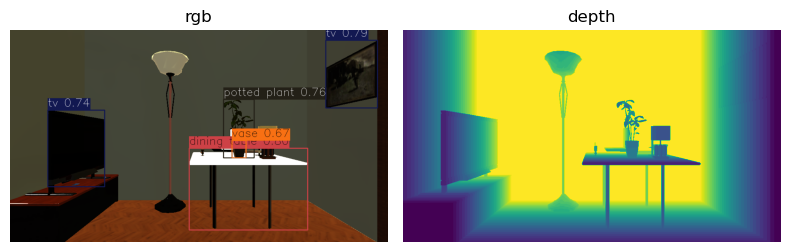

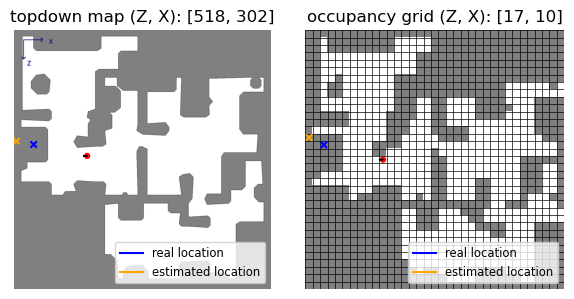


Target object <potted plant> found after 11 actions!
Found location: [    -10.376    -0.10844      6.2671]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 11
Travelled distance: 1.52 m
Computed location error: 0.719 m


Simulation 40/100


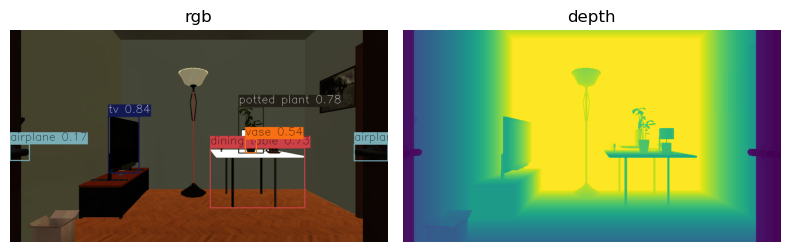

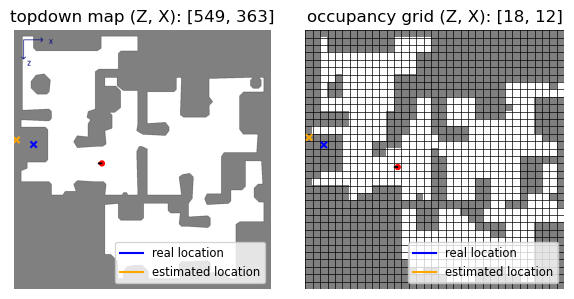


Target object <potted plant> found after 60 actions!
Found location: [    -10.375    -0.11025      6.2183]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 60
Travelled distance: 3.95 m
Computed location error: 0.730 m


Simulation 41/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 34.07 m
Computed location error: inf m


Simulation 42/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 35.27 m
Computed location error: inf m


Simulation 43/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 22.81 m
Computed location error: i

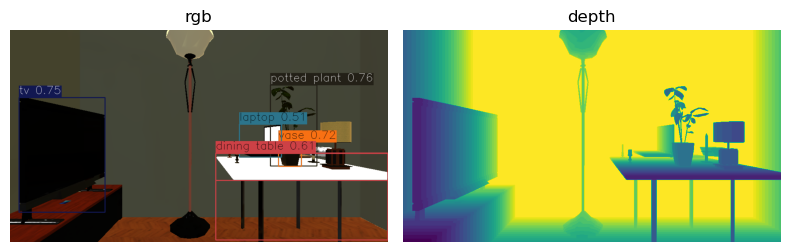

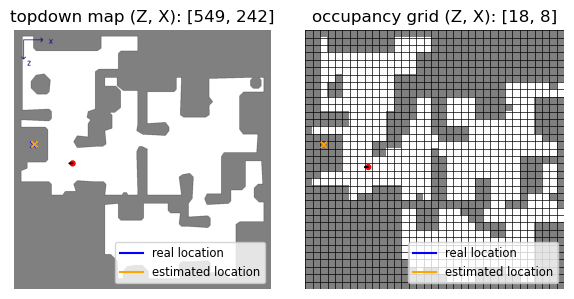


Target object <potted plant> found after 10 actions!
Found location: [    -9.6371   -0.086293       6.394]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 10
Travelled distance: 0.61 m
Computed location error: 0.038 m


Simulation 47/100

Location error 1.121 m exceeds threshold 0.8 m. FAILURE!


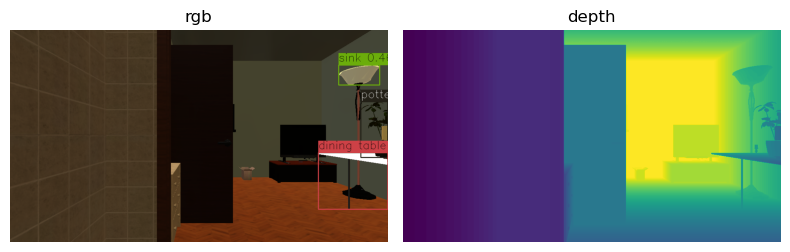

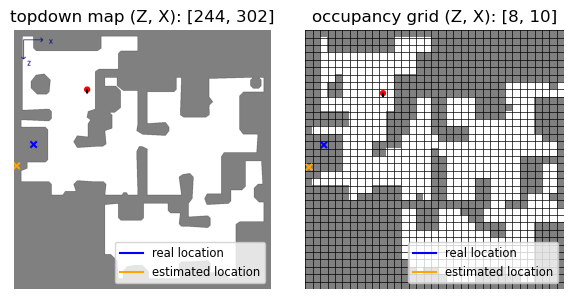


Target object <potted plant> not found after 300 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 300
Travelled distance: 23.39 m
Computed location error: 1.121 m


Simulation 48/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 27.05 m
Computed location error: inf m


Simulation 49/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 27.06 m
Computed location error: inf m


Simulation 50/100


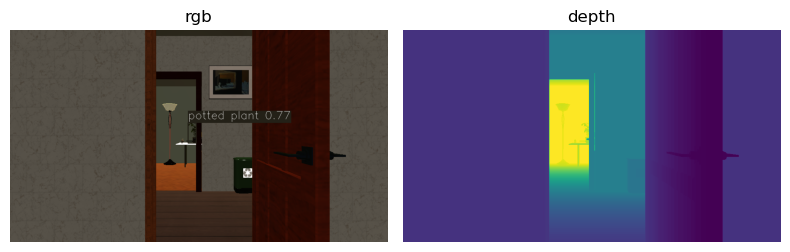

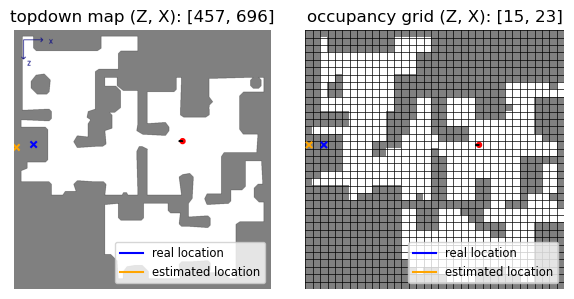


Target object <potted plant> found after 18 actions!
Found location: [    -10.376     -0.1072      6.5222]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 18
Travelled distance: 1.83 m
Computed location error: 0.713 m


Simulation 51/100


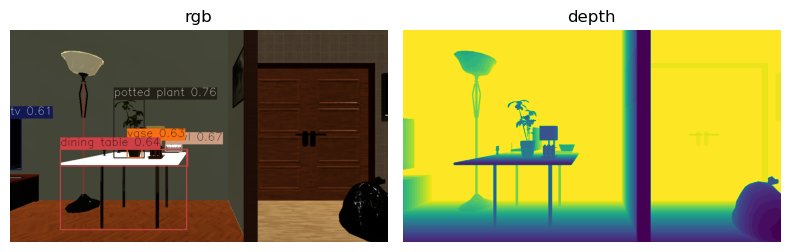

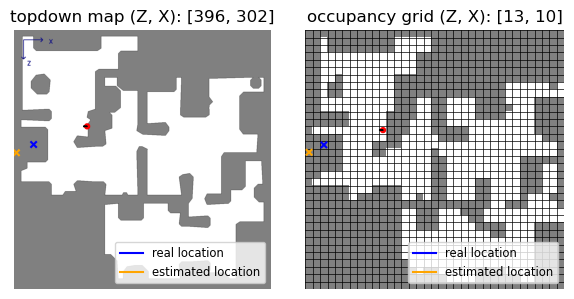


Target object <potted plant> found after 2 actions!
Found location: [    -10.376    -0.10844      6.7417]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 2
Travelled distance: 0.00 m
Computed location error: 0.778 m


Simulation 52/100


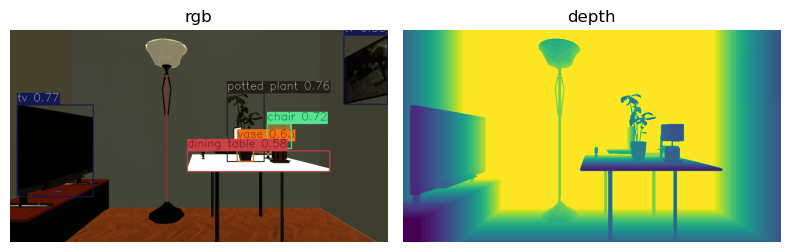

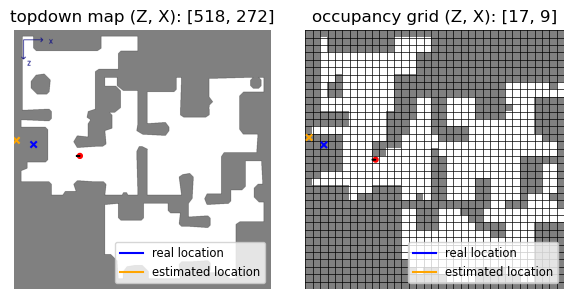


Target object <potted plant> found after 5 actions!
Found location: [    -10.375    -0.11766      6.2333]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 5
Travelled distance: 0.61 m
Computed location error: 0.726 m


Simulation 53/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 26.73 m
Computed location error: inf m


Simulation 54/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 31.02 m
Computed location error: inf m


Simulation 55/100


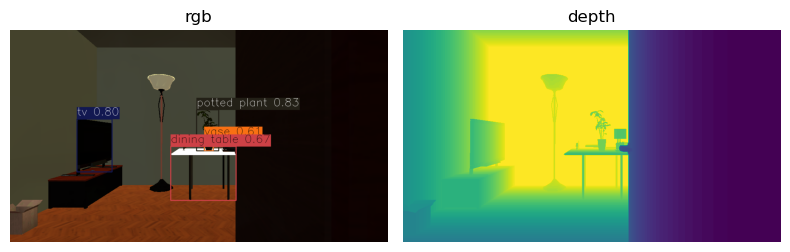

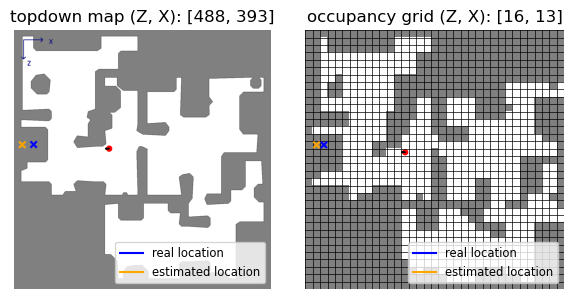


Target object <potted plant> found after 13 actions!
Found location: [    -10.134    -0.10518      6.4114]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 13
Travelled distance: 0.91 m
Computed location error: 0.463 m


Simulation 56/100

Location error 1.118 m exceeds threshold 0.8 m. FAILURE!


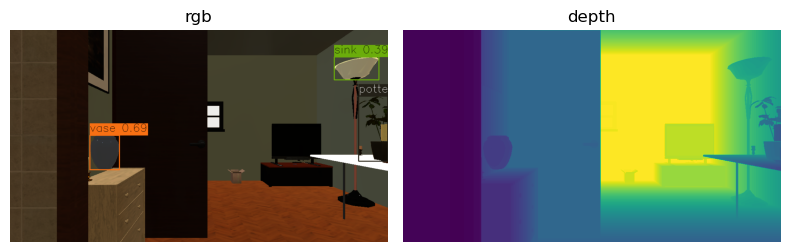

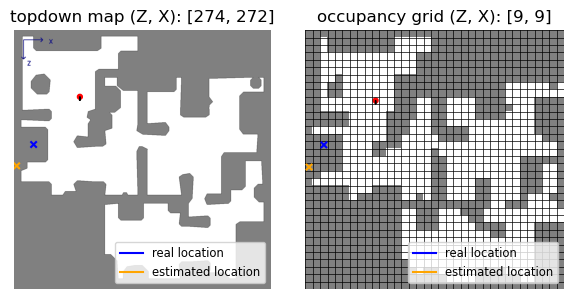


Target object <potted plant> not found after 40 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 40
Travelled distance: 5.47 m
Computed location error: 1.118 m


Simulation 57/100


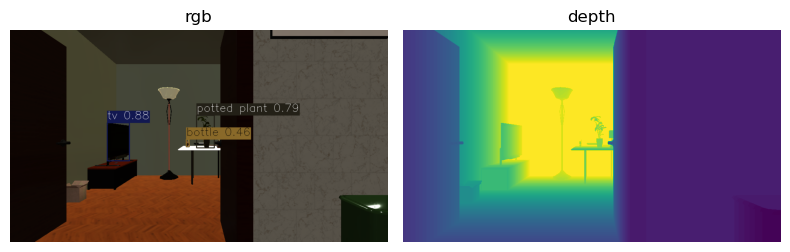

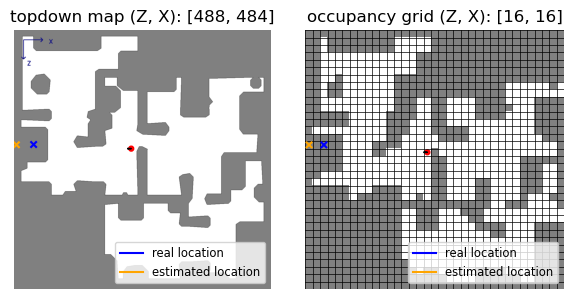


Target object <potted plant> found after 232 actions!
Found location: [    -10.376    -0.10184      6.4153]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 232
Travelled distance: 14.30 m
Computed location error: 0.704 m


Simulation 58/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 21.30 m
Computed location error: inf m


Simulation 59/100


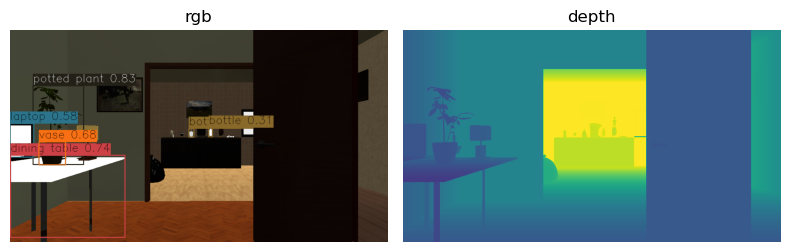

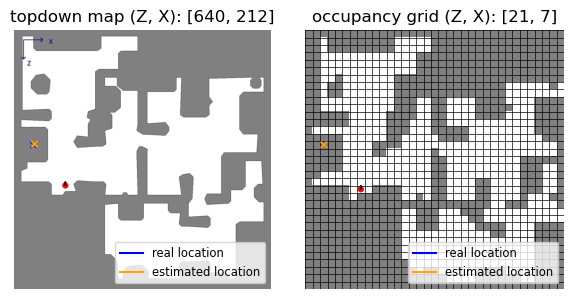


Target object <potted plant> found after 1 actions!
Found location: [    -9.6403   -0.097036      6.3853]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 1
Travelled distance: 0.00 m
Computed location error: 0.040 m


Simulation 60/100


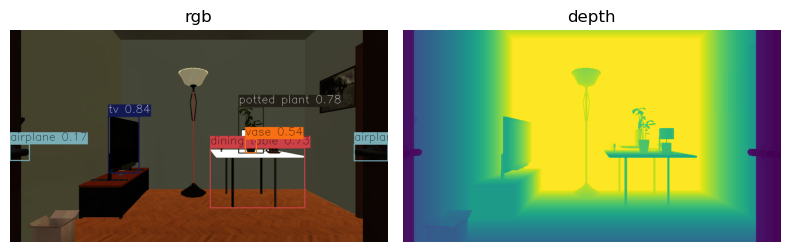

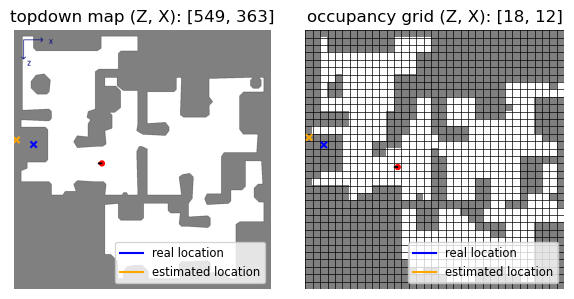


Target object <potted plant> found after 3 actions!
Found location: [    -10.375    -0.11025      6.2183]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 3
Travelled distance: 0.00 m
Computed location error: 0.730 m


Simulation 61/100

Location error 0.936 m exceeds threshold 0.8 m. FAILURE!


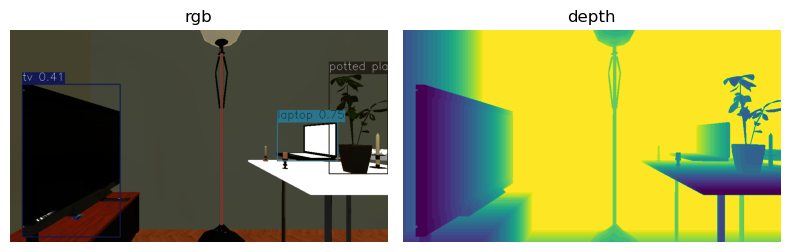

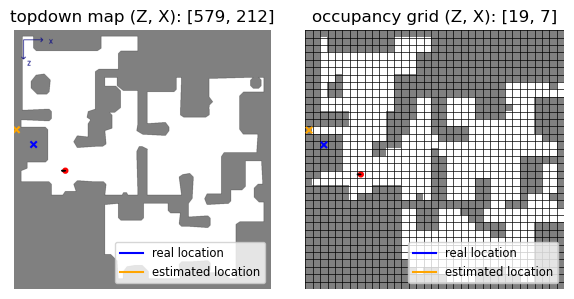


Target object <potted plant> not found after 9 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 9
Travelled distance: 0.61 m
Computed location error: 0.936 m


Simulation 62/100

Location error 1.200 m exceeds threshold 0.8 m. FAILURE!


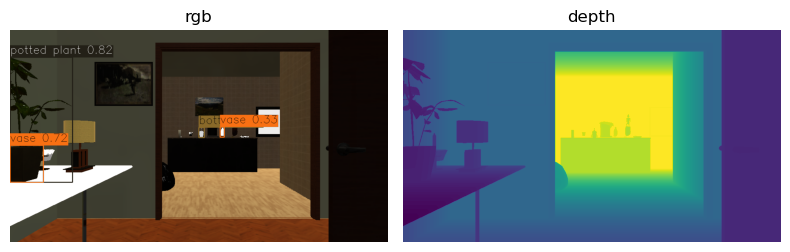

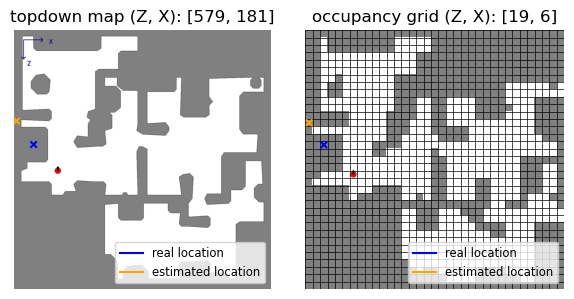


Target object <potted plant> not found after 2 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 2
Travelled distance: 0.00 m
Computed location error: 1.200 m


Simulation 63/100

Location error 1.121 m exceeds threshold 0.8 m. FAILURE!


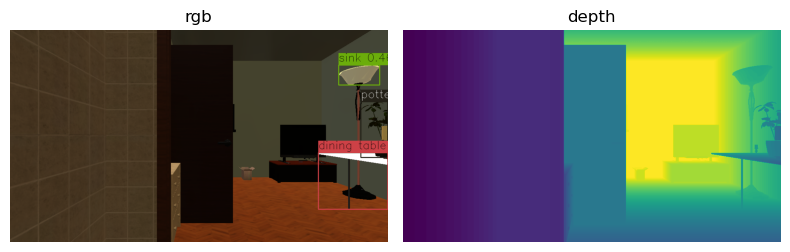

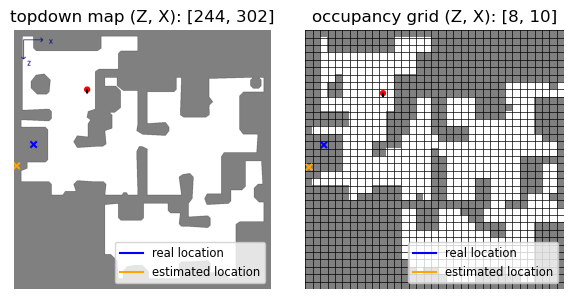


Target object <potted plant> not found after 124 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 124
Travelled distance: 13.70 m
Computed location error: 1.121 m


Simulation 64/100


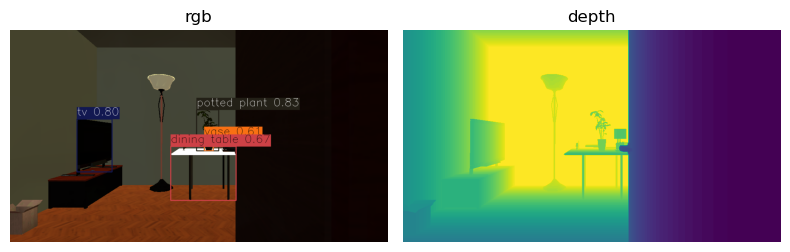

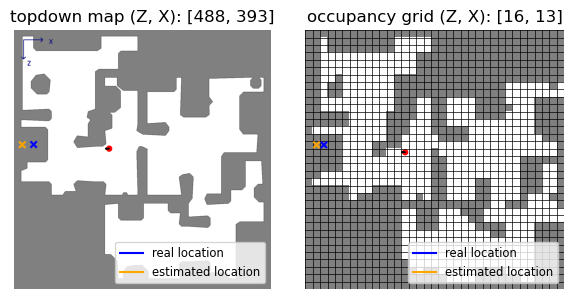


Target object <potted plant> found after 335 actions!
Found location: [    -10.134    -0.10518      6.4114]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 335
Travelled distance: 22.22 m
Computed location error: 0.463 m


Simulation 65/100

Location error 1.115 m exceeds threshold 0.8 m. FAILURE!


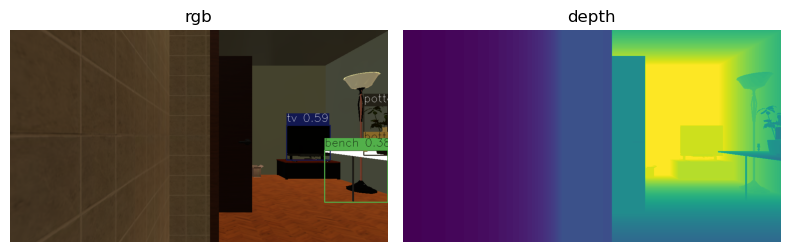

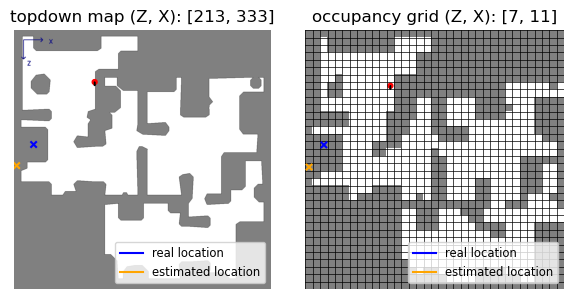


Target object <potted plant> not found after 148 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 148
Travelled distance: 10.95 m
Computed location error: 1.115 m


Simulation 66/100


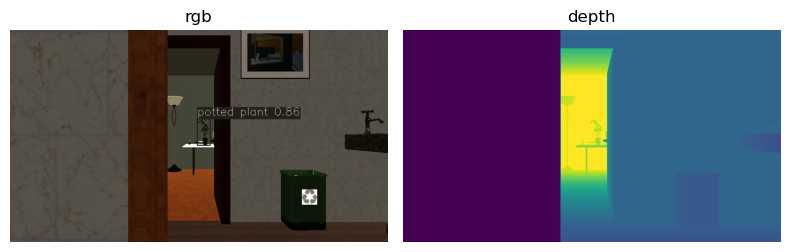

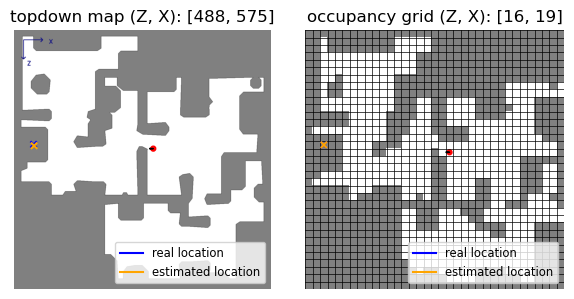


Target object <potted plant> found after 10 actions!
Found location: [    -9.6516   -0.096191      6.4573]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 10
Travelled distance: 0.91 m
Computed location error: 0.051 m


Simulation 67/100


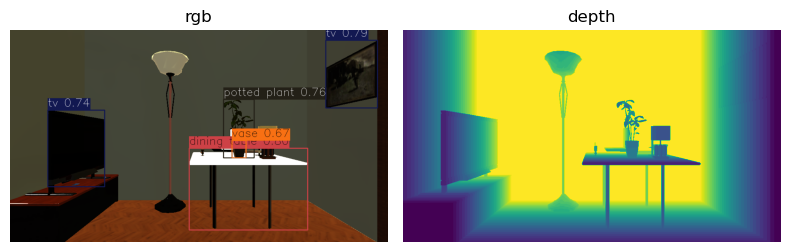

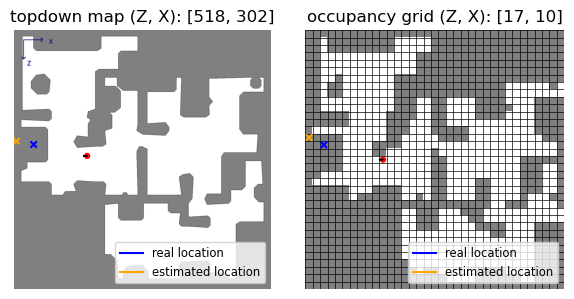


Target object <potted plant> found after 9 actions!
Found location: [    -10.376    -0.10844      6.2671]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 9
Travelled distance: 1.82 m
Computed location error: 0.719 m


Simulation 68/100


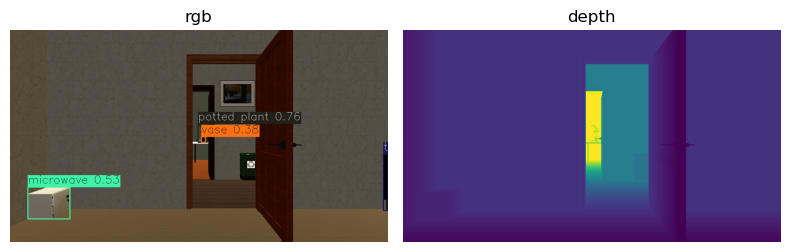

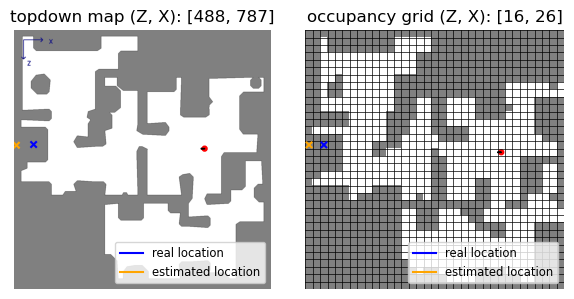


Target object <potted plant> found after 272 actions!
Found location: [    -10.375    -0.10622      6.4361]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 272
Travelled distance: 19.76 m
Computed location error: 0.705 m


Simulation 69/100


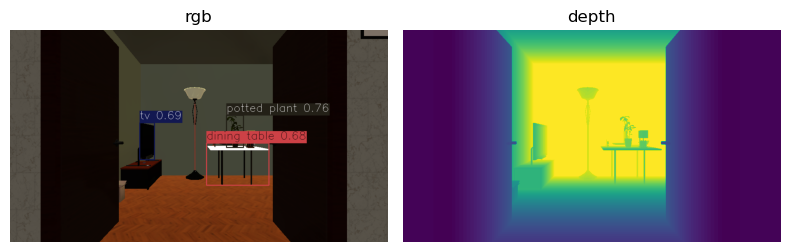

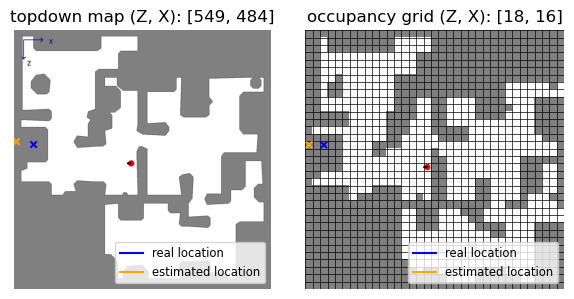


Target object <potted plant> found after 10 actions!
Found location: [    -10.376    -0.11109       6.285]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 10
Travelled distance: 0.31 m
Computed location error: 0.715 m


Simulation 70/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 24.62 m
Computed location error: inf m


Simulation 71/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 29.81 m
Computed location error: inf m


Simulation 72/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 28.28 m
Computed location error: i

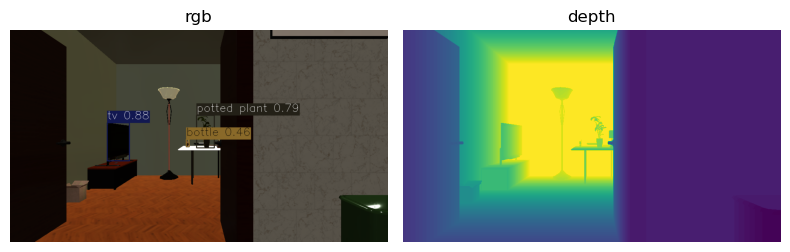

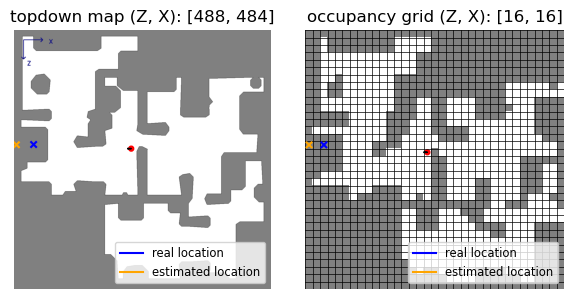


Target object <potted plant> found after 5 actions!
Found location: [    -10.376    -0.10184      6.4153]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 5
Travelled distance: 0.30 m
Computed location error: 0.704 m


Simulation 74/100


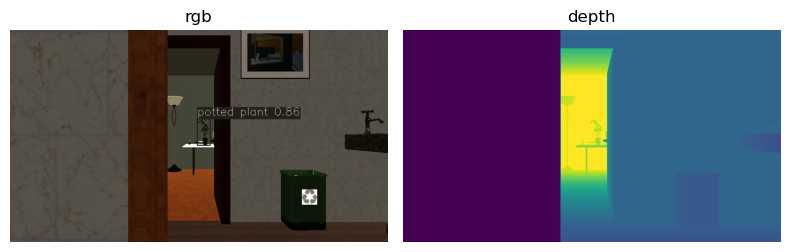

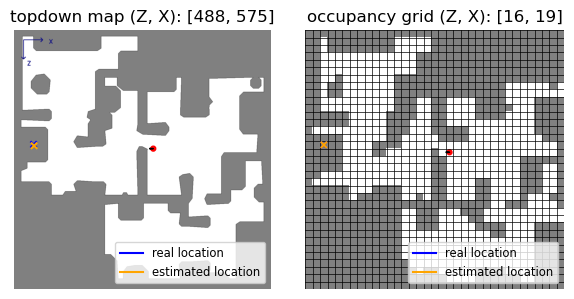


Target object <potted plant> found after 383 actions!
Found location: [    -9.6516   -0.096191      6.4573]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 383
Travelled distance: 28.91 m
Computed location error: 0.051 m


Simulation 75/100


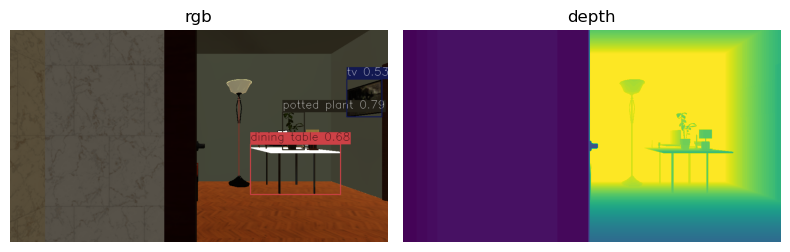

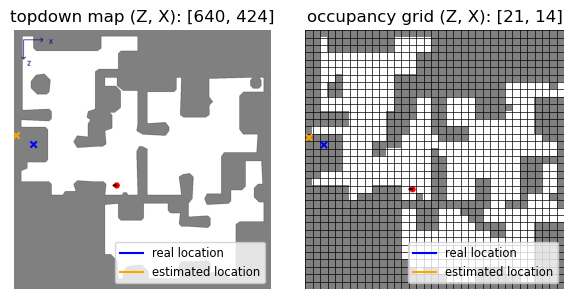


Target object <potted plant> found after 9 actions!
Found location: [    -10.376    -0.10497      6.0394]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 9
Travelled distance: 1.22 m
Computed location error: 0.796 m


Simulation 76/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 32.56 m
Computed location error: inf m


Simulation 77/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 29.80 m
Computed location error: inf m


Simulation 78/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 30.12 m
Computed location error: inf

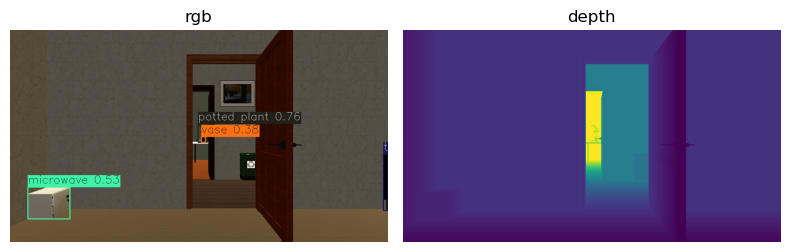

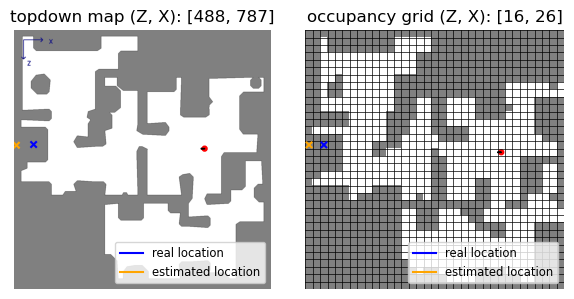


Target object <potted plant> found after 103 actions!
Found location: [    -10.375    -0.10622      6.4361]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 103
Travelled distance: 5.76 m
Computed location error: 0.705 m


Simulation 81/100


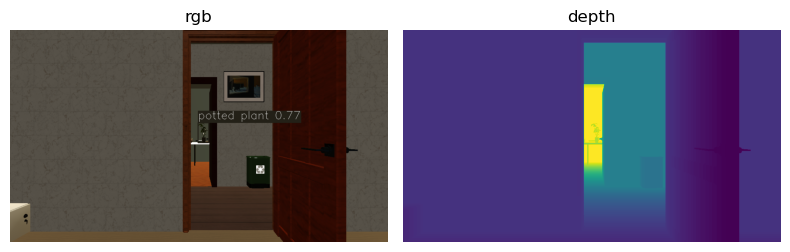

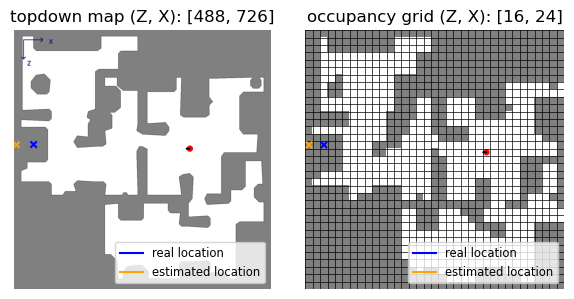


Target object <potted plant> found after 350 actions!
Found location: [    -10.375    -0.11193      6.4188]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 350
Travelled distance: 21.59 m
Computed location error: 0.704 m


Simulation 82/100


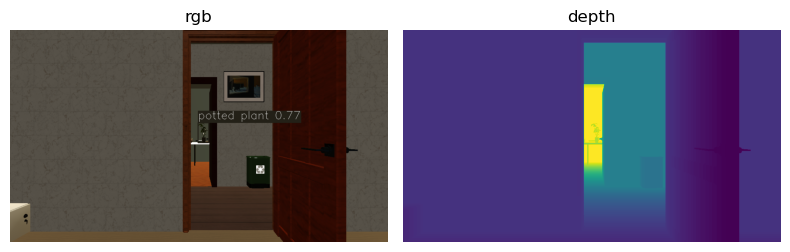

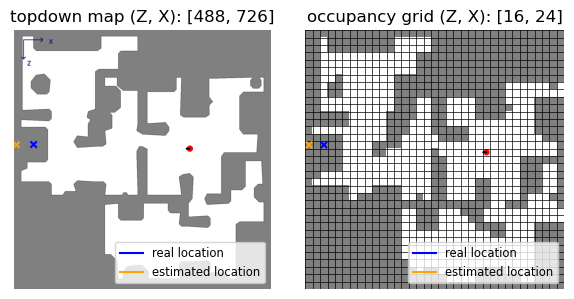


Target object <potted plant> found after 235 actions!
Found location: [    -10.375    -0.11193      6.4188]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 235
Travelled distance: 13.38 m
Computed location error: 0.704 m


Simulation 83/100


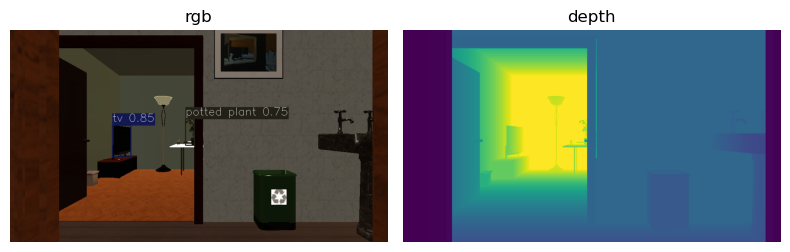

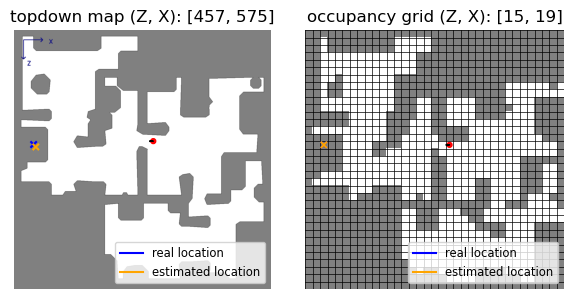


Target object <potted plant> found after 398 actions!
Found location: [    -9.5789   -0.094772      6.5045]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 398
Travelled distance: 30.72 m
Computed location error: 0.132 m


Simulation 84/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 26.76 m
Computed location error: inf m


Simulation 85/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 32.51 m
Computed location error: inf m


Simulation 86/100

Location error 1.125 m exceeds threshold 0.8 m. FAILURE!


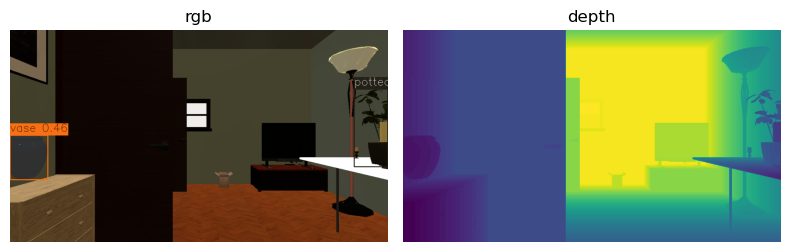

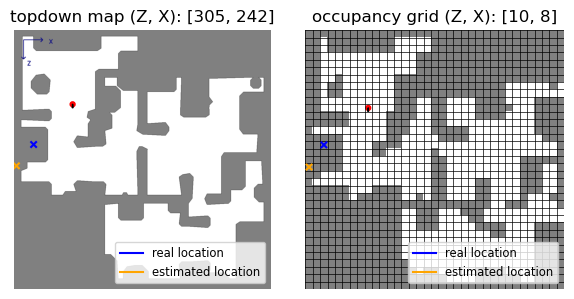


Target object <potted plant> not found after 4 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 4
Travelled distance: 0.31 m
Computed location error: 1.125 m


Simulation 87/100

Location error 0.961 m exceeds threshold 0.8 m. FAILURE!


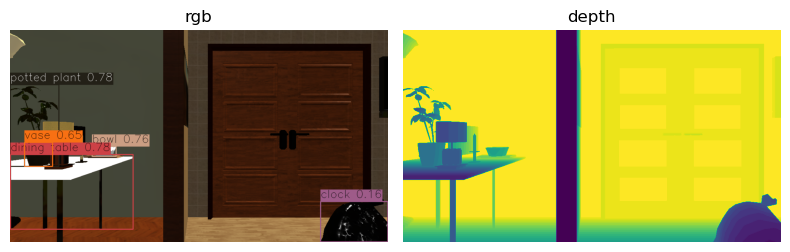

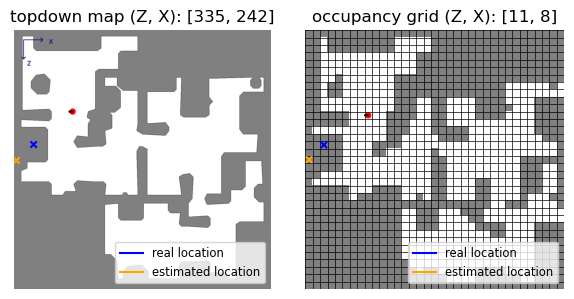


Target object <potted plant> not found after 355 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 355
Travelled distance: 20.67 m
Computed location error: 0.961 m


Simulation 88/100

Location error 1.121 m exceeds threshold 0.8 m. FAILURE!


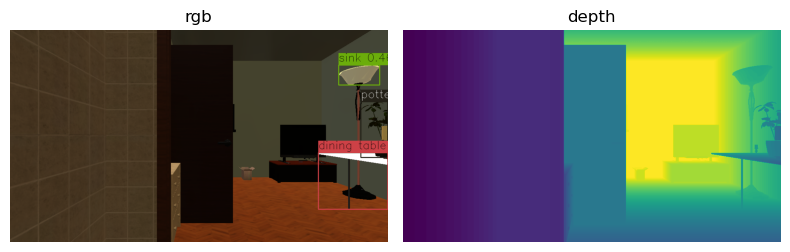

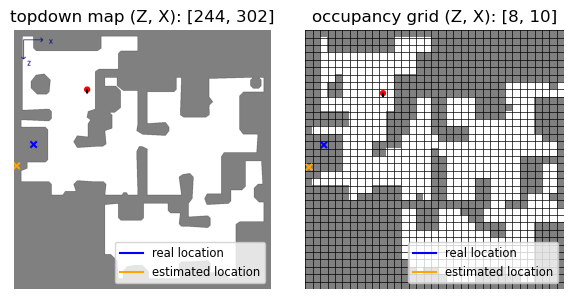


Target object <potted plant> not found after 105 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 105
Travelled distance: 10.04 m
Computed location error: 1.121 m


Simulation 89/100

Location error 1.125 m exceeds threshold 0.8 m. FAILURE!


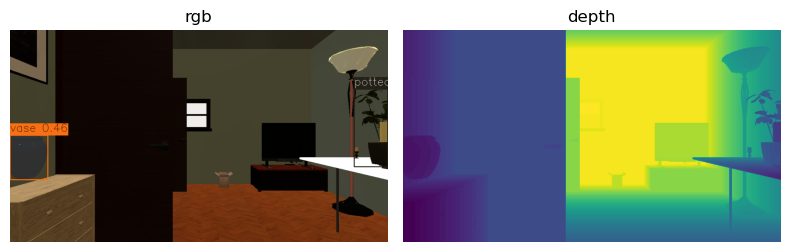

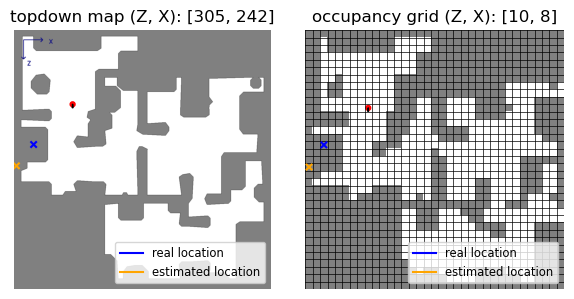


Target object <potted plant> not found after 23 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 23
Travelled distance: 1.83 m
Computed location error: 1.125 m


Simulation 90/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 30.09 m
Computed location error: inf m


Simulation 91/100

Location error 1.118 m exceeds threshold 0.8 m. FAILURE!


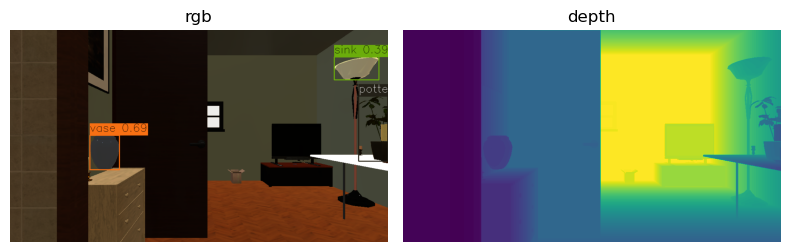

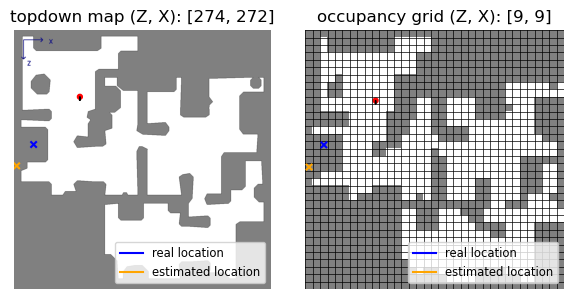


Target object <potted plant> not found after 67 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 67
Travelled distance: 4.56 m
Computed location error: 1.118 m


Simulation 92/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 29.50 m
Computed location error: inf m


Simulation 93/100

Location error 1.118 m exceeds threshold 0.8 m. FAILURE!


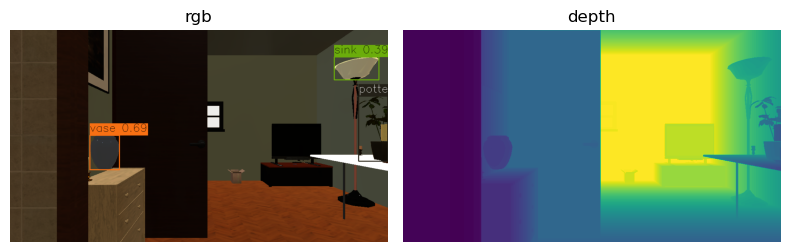

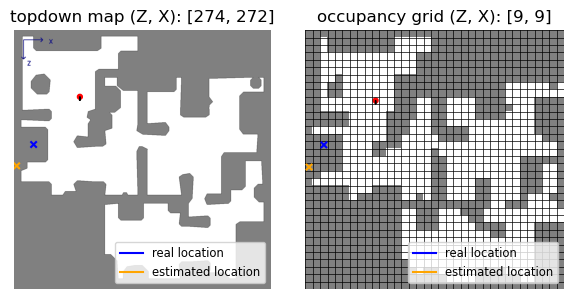


Target object <potted plant> not found after 13 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 13
Travelled distance: 1.52 m
Computed location error: 1.118 m


Simulation 94/100


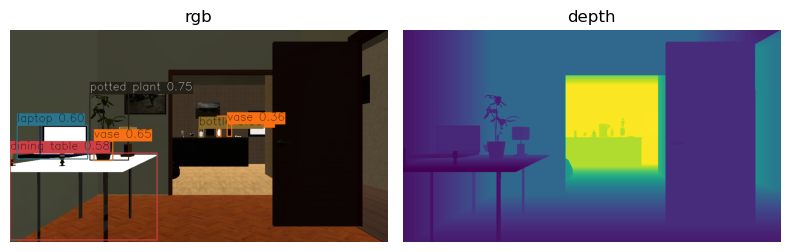

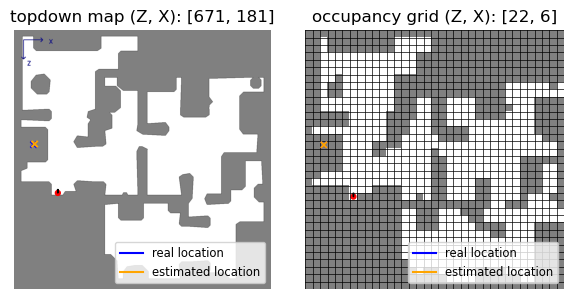


Target object <potted plant> found after 2 actions!
Found location: [    -9.6263   -0.094548      6.3866]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 2
Travelled distance: 0.00 m
Computed location error: 0.051 m


Simulation 95/100


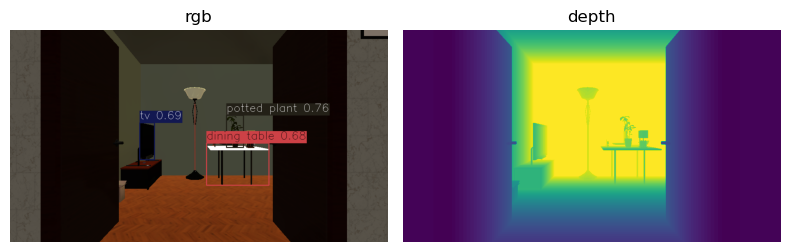

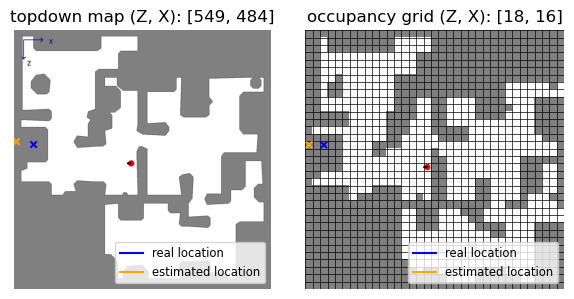


Target object <potted plant> found after 4 actions!
Found location: [    -10.376    -0.11109       6.285]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 4
Travelled distance: 0.61 m
Computed location error: 0.715 m


Simulation 96/100


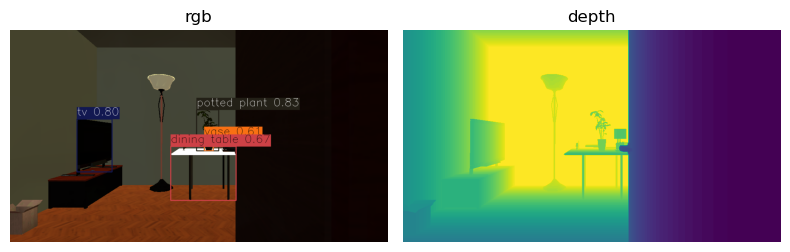

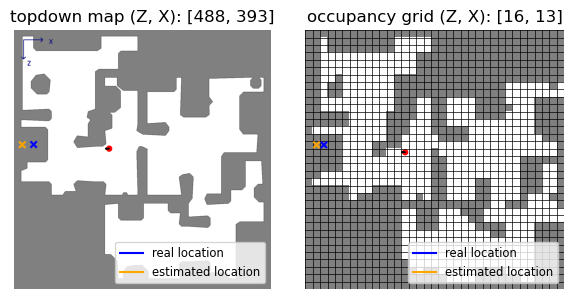


Target object <potted plant> found after 195 actions!
Found location: [    -10.134    -0.10518      6.4114]
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 195
Travelled distance: 14.90 m
Computed location error: 0.463 m


Simulation 97/100

Location error 0.878 m exceeds threshold 0.8 m. FAILURE!


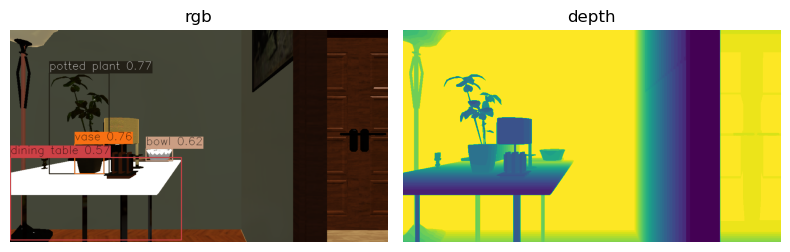

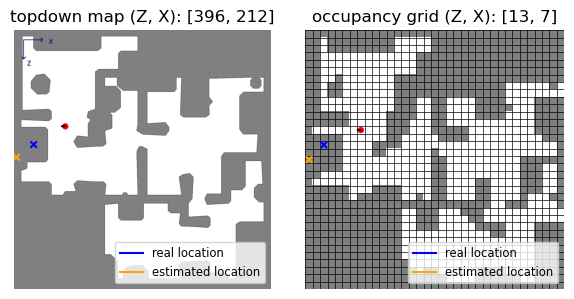


Target object <potted plant> not found after 3 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 3
Travelled distance: 0.00 m
Computed location error: 0.878 m


Simulation 98/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 29.82 m
Computed location error: inf m


Simulation 99/100

Target object <potted plant> not found after 406 actions!
Ground-truth location: [-9.671131365001202, 0.7431214153766632, 6.410288855433464]
Number of actions: 406
Travelled distance: 30.72 m
Computed location error: inf m


In [8]:
for index, (GRID_POSITION, AGENT_YAW) in enumerate(zip(starting_grid_positions, starting_orientations)):

    # Initialize an agent
    agent = sim.initialize_agent(sim_settings["default_agent"])

    # Sample a random position (within the possible ones)
    grid_position = GRID_POSITION
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]

    # Sample a random yaw rotation
    agent_yaw = AGENT_YAW  # in degrees
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    # Set agent state
    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Compute agent radius in both maps
    min_bounds, max_bounds = sim.pathfinder.get_bounds()
    x_dim = max_bounds[0] - min_bounds[0]
    topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
    grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

    # Get initial agent position tuple and radius tuple
    agent_radius = (topdown_radius, grid_radius)
    agent_positions = (map_position, grid_position)

    # Get initial observations and maps
    observations = sim.get_sensor_observations(0)
    rgb = observations["color_sensor"]
    depth = observations["depth_sensor"]

    # Display the initial simulation state (maps + observations)
    print(f"\n\nSimulation {index}/{len(starting_grid_positions)}")
    #simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

    # Metrics initialization
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")

    # Simulation parameters
    MAX_ITER = int(num_free_cells * MAX_ITER_COEF)  # Maximum number of actions to perform

    # Main simulation loop
    while (num_actions < MAX_ITER) and (not target_found):

        # Select an action randomly
        action = random.choice(list(ACTIONS))
        num_actions += 1

        # Check if the action is valid
        if not simtools.is_action_valid(action, grid_position, agent_yaw, grid_free_cells):
            continue 
        
        # Perform the action and update agent state
        grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
        
        # Update the agent position and orientation
        idx = grid_free_cells.index(grid_position)
        map_position, world_position = map_free_cells[idx], world_free_coords[idx]
        agent_quart = myutils.yaw_to_quaternion(agent_yaw)
        agent_positions = (map_position, grid_position)

        # Compute travelled distance
        travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

        # Set agent state
        agent_state.position = world_position
        agent_state.rotation = agent_quart
        agent.set_state(agent_state)

        # Get observations
        obs = sim.get_sensor_observations(0)
        rgb, depth = obs["color_sensor"], obs["depth_sensor"]

        # YOLO Prediction
        results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
        detections = simtools.parse_yolo_detections(results)
        simtools.merge_rgb_yolo_outputs(rgb, detections)
        target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

    # Compute the target location if it was found
    if target_found:
        # Real world position
        center_x, center_y = simtools.get_box_center(target_bbox)
        depth_value = depth[center_y, center_x]
        target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)

    # Evaluating correctness of the target detection
    if target_found:
        # Location error
        location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

        # Compare with threshold
        if location_error > LOCATION_ERROR_THRESHOLD:
            print(f"\nLocation error {location_error:.3f} m exceeds threshold {LOCATION_ERROR_THRESHOLD} m. FAILURE!")
            target_found = False

        # Plot maps with target
        target_positions = simtools.get_2d_coords(target_location, topdown_resolution, grid_resolution, sim.pathfinder)
        real_target_positions = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
        simtools.display_sim_observations(rgb, depth)
        simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_positions, real_target_positions)

    # Display simulation result and metrics
    if target_found:
        print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
        print(f"Found location: {target_location}")
    else:
        print(f"\nTarget object <{TARGET_OBJECT}> not found after {num_actions} actions!")

    print(f"Ground-truth location: {REAL_TARGET_LOCATION}")
    print(f"Number of actions: {num_actions}")
    print(f"Travelled distance: {travelled_distance:.2f} m")
    print(f"Computed location error: {location_error:.3f} m")

    # Store metrics
    num_actions_epochs.append(num_actions)
    travelled_distance_epochs.append(travelled_distance)
    success_epochs.append(target_found)
    location_error_epochs.append(location_error)


In [9]:
import numpy as np

# Pre-process
num_actions_epochs = np.array(num_actions_epochs)
travelled_distance_epochs = np.array(travelled_distance_epochs)
success_epochs = np.array(success_epochs)
location_error_epochs = np.array(location_error_epochs)

# Counting
num_total_epochs = len(num_actions_epochs)
num_success_epochs = np.sum(success_epochs)

# Metrics on all runs
total_avg_num_actions = np.sum(num_actions_epochs) / num_total_epochs
total_avg_tavelled_distance = np.sum(travelled_distance_epochs) / num_total_epochs
success_rate = num_success_epochs / num_total_epochs * 100

# Metrics on successful runs
success_avg_travelled_distance = np.sum(travelled_distance_epochs[success_epochs]) / num_success_epochs
success_avg_num_actions = np.sum(num_actions_epochs[success_epochs]) / num_success_epochs
success_avg_location_error = np.sum(location_error_epochs[success_epochs]) / num_success_epochs

#Print final metrics
print("\n\nMETRICS:\n")
print(f"Total number of epochs: {num_total_epochs}")
print(f"Number of successful epochs: {num_success_epochs}")
print(f"Success rate: {success_rate:.2f}%")
print(f"Average number of actions (epochs): {total_avg_num_actions:.2f}")
print(f"Average travelled distance (epochs): {total_avg_tavelled_distance:.2f} m")
print(f"Average success rate (epochs): {success_rate:.2f}%")
print(f"\nAverage number of actions (successful epochs): {success_avg_num_actions:.2f}")
print(f"Average travelled distance (successful epochs): {success_avg_travelled_distance:.2f} m")
print(f"Average location error (successful epochs): {success_avg_location_error:.3f} m")

# Number of actions max, min and std
print(f"\nMax number of actions (epochs): {np.max(num_actions_epochs)}")
print(f"Min number of actions (epochs): {np.min(num_actions_epochs)}")
print(f"Std number of actions (epochs): {np.std(num_actions_epochs)}")    



METRICS:

Total number of epochs: 100
Number of successful epochs: 38
Success rate: 38.00%
Average number of actions (epochs): 214.11
Average travelled distance (epochs): 15.18 m
Average success rate (epochs): 38.00%

Average number of actions (successful epochs): 92.08
Average travelled distance (successful epochs): 6.53 m
Average location error (successful epochs): 0.521 m

Max number of actions (epochs): 406
Min number of actions (epochs): 1
Std number of actions (epochs): 179.9506540693865


In [ ]:
metrics_file = 'results/metrics.json'

# Load existing metrics if the file exists, otherwise start with an empty list
if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        existing_metrics = json.load(f)
else:
    existing_metrics = []

# New metrics entry (convert numpy types to native Python types)
def to_python_type(val):
    if hasattr(val, "item"):
        return val.item()
    return val

new_metrics = {
    "simulation_index": to_python_type(INDEX),
    "scene": SCENE,
    "target_object": TARGET_OBJECT,
    "search_method": METHOD,
    "confidence_threshold": to_python_type(CONFIDENCE_THRESHOLD),
    "max_iter_coefficient": to_python_type(MAX_ITER_COEF),
    "location_error_threshold": to_python_type(LOCATION_ERROR_THRESHOLD),
    "pseudo_count_threshold": to_python_type(PSEUDO_COUNT_THRESHOLD),
    "num_total_epochs": to_python_type(num_total_epochs),
    "num_success_epochs": to_python_type(num_success_epochs),
    "success_rate": to_python_type(success_rate),
    "total_avg_num_actions": to_python_type(total_avg_num_actions),
    "total_avg_tavelled_distance": to_python_type(total_avg_tavelled_distance),
    "success_avg_num_actions": to_python_type(success_avg_num_actions),
    "success_avg_travelled_distance": to_python_type(success_avg_travelled_distance),
    "success_avg_location_error": to_python_type(success_avg_location_error),
}

# Check for duplicate (by simulation_index and search_method)
duplicate_exists = any(
    entry["simulation_index"] == new_metrics["simulation_index"] and
    entry["search_method"] == new_metrics["search_method"] 
    for entry in existing_metrics
)

if not duplicate_exists:
    existing_metrics.append(new_metrics)
else:
    print(f"Metrics for simulation_index {new_metrics['simulation_index']} and search_method '{new_metrics['search_method']}' already exist. Skipping append.")

# Save updated metrics list
with open(metrics_file, 'w') as f:
    json.dump(existing_metrics, f, indent=4)

print(f"\nMetrics saved to {metrics_file}")

In [ ]:
sim.close()  # Close the simulator